In [1]:
#Tratamiento de datos
import pandas as pd
pd.set_option('display.max_columns',None)


import sys
sys.path.append('../')

from SRC import sp_nulos as sn
from SRC import sp_visualizaciones_eda as sv
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_no_nulos=pd.read_csv("../datos/df_data_no_nulos.csv", parse_dates=['date_contact', 'dt_customer'])

# DISTRIBUCION DE COLUMNAS CATEGORICAS

### VISUALIZACION DE FRECUENCIAS

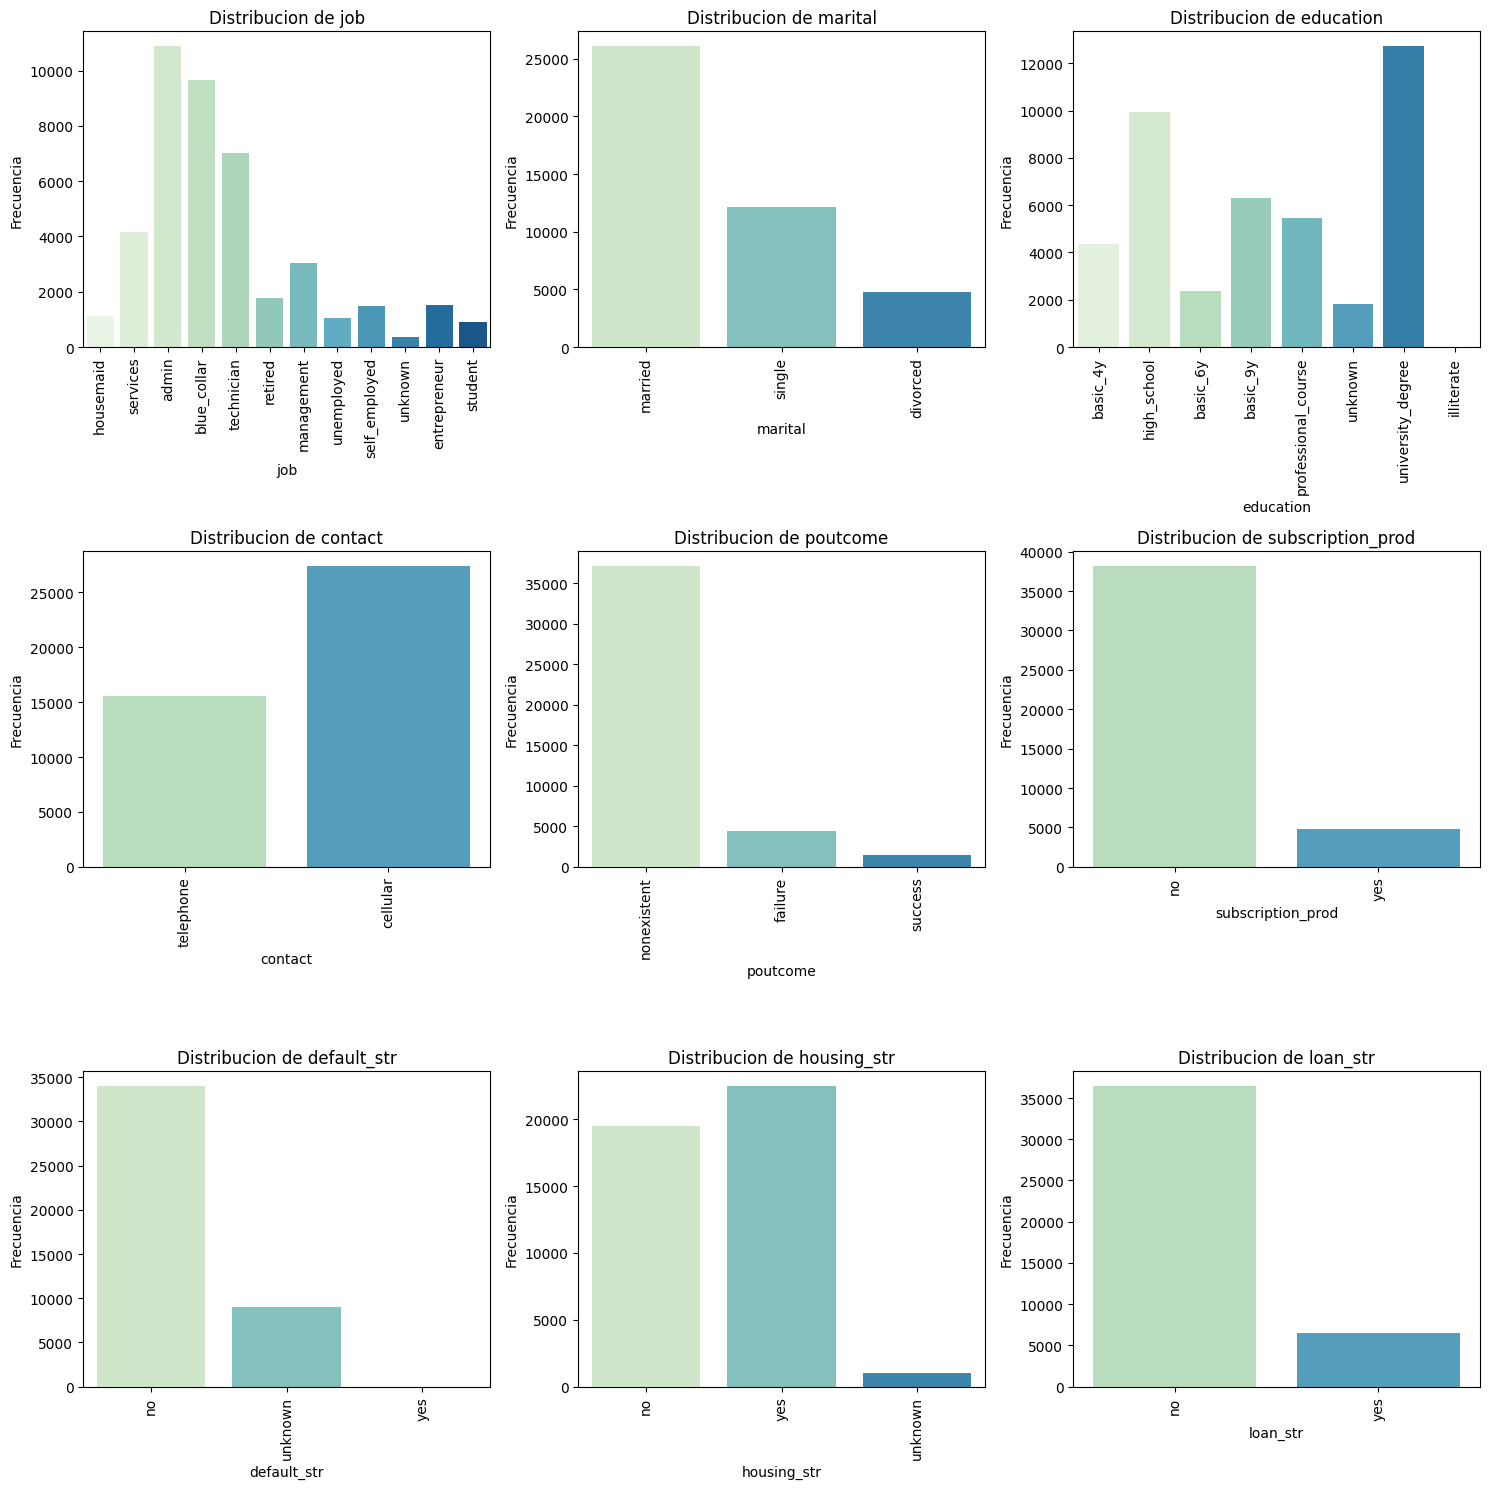

In [3]:
sn.subplot_col_cat(df_no_nulos.drop(columns=['id']))

### CALCULO DE FRECUENCIAS

In [4]:

for col in df_no_nulos.select_dtypes(include='object').columns:
    print(col.upper())
    print(df_no_nulos[col].value_counts()/df_no_nulos.shape[0]*100)
    print ('------------------------')

JOB
job
admin            25.286047
blue_collar      22.451163
technician       16.339535
services          9.679070
management        7.093023
retired           4.162791
entrepreneur      3.539535
self_employed     3.462791
housemaid         2.611628
unemployed        2.472093
student           2.100000
unknown           0.802326
Name: count, dtype: float64
------------------------
MARITAL
marital
married     60.660465
single      28.151163
divorced    11.188372
Name: count, dtype: float64
------------------------
EDUCATION
education
university_degree      29.586047
high_school            23.081395
basic_9y               14.672093
professional_course    12.737209
basic_4y               10.130233
basic_6y                5.548837
unknown                 4.202326
illiterate              0.041860
Name: count, dtype: float64
------------------------
CONTACT
contact
cellular     63.711628
telephone    36.288372
Name: count, dtype: float64
------------------------
POUTCOME
poutcome
nonexisten

**job** La mayoria de los clientes contactados trabajan en sectores administrativos (25%), obreros o industriales (22%) y tecnicos (16%), mientras que colectivos como estudiantes (2%) o desempleados (2.4%) son minoritarios. 

Los bancos tienden a dirigir las campañas a personas con empleo estable y capacidad de ahorro. Profesiones como "retired" o "management" podrían mostrar una mayor propension a contratar productos financieros por su perfil economico.

**marital** Predominan los casados (61%), seguidos de solteros (28%) y divorciados (11%). 

Los casados suelen representar el segmento de clientes con mayor estabilidad financiera y decisiones mas conservadoras, mientras que los solteros pueden mostrar mayor receptividad a nuevos productos. Es un punto interesante para segmentar estrategias de marketing.

**education** Casi un 30% posee título universitario, seguido de formación secundaria (23%) y distintos niveles de educacion basica. Solo un 0.04% son analfabetos (illiterate). 

Un nivel educativo mas alto puede relacionarse con mayor conocimiento financiero y, por tanto, mayor predisposición a comprender y contratar productos bancarios complejos.
El grupo "unknown" (4.2%) puede distorsionar conclusiones.

**contact** El 63.7% fue contactado por móvil y el 36.3% por teléfono fijo. 

Puede reflejar una mayor modernización del canal de contacto. Los clientes contactados por móvil podrían mostrar tasas de éxito mayores, ya que el canal es más directo y personal.

**poutcome** Una gran mayoría (86%) no participó en campañas previas, un 10% tuvo un resultado fallido y solo un 3.3% tuvo éxito. 

Las campañas anteriores no lograron gran conversión, pero los que sí lo hicieron podrían representar un perfil de cliente leal, útil para estrategias de retención.

**subscription_pro** Solo un 11.3% contrató el producto frente a un 88.7% que no lo hizo. 

La campaña tiene una baja tasa de conversión.

**default_str** La gran mayoría no tiene deudas impagadas (79%), aunque hay un 21% de valores desconocidos.

**housing_str** Un 52.3% tiene hipoteca, un 45.3% no y un 2.4% se desconoce.

**Loan_str** Un 15.2% tiene préstamos personales, frente al 84.8% que no.
los clientes sin préstamos activos podrían tener mayor capacidad para invertir o contratar productos financieros.



# DISTRIBUCION DE COLUMNAS NUMERICAS

### VISUALIZACION DE FRECUENCIAS

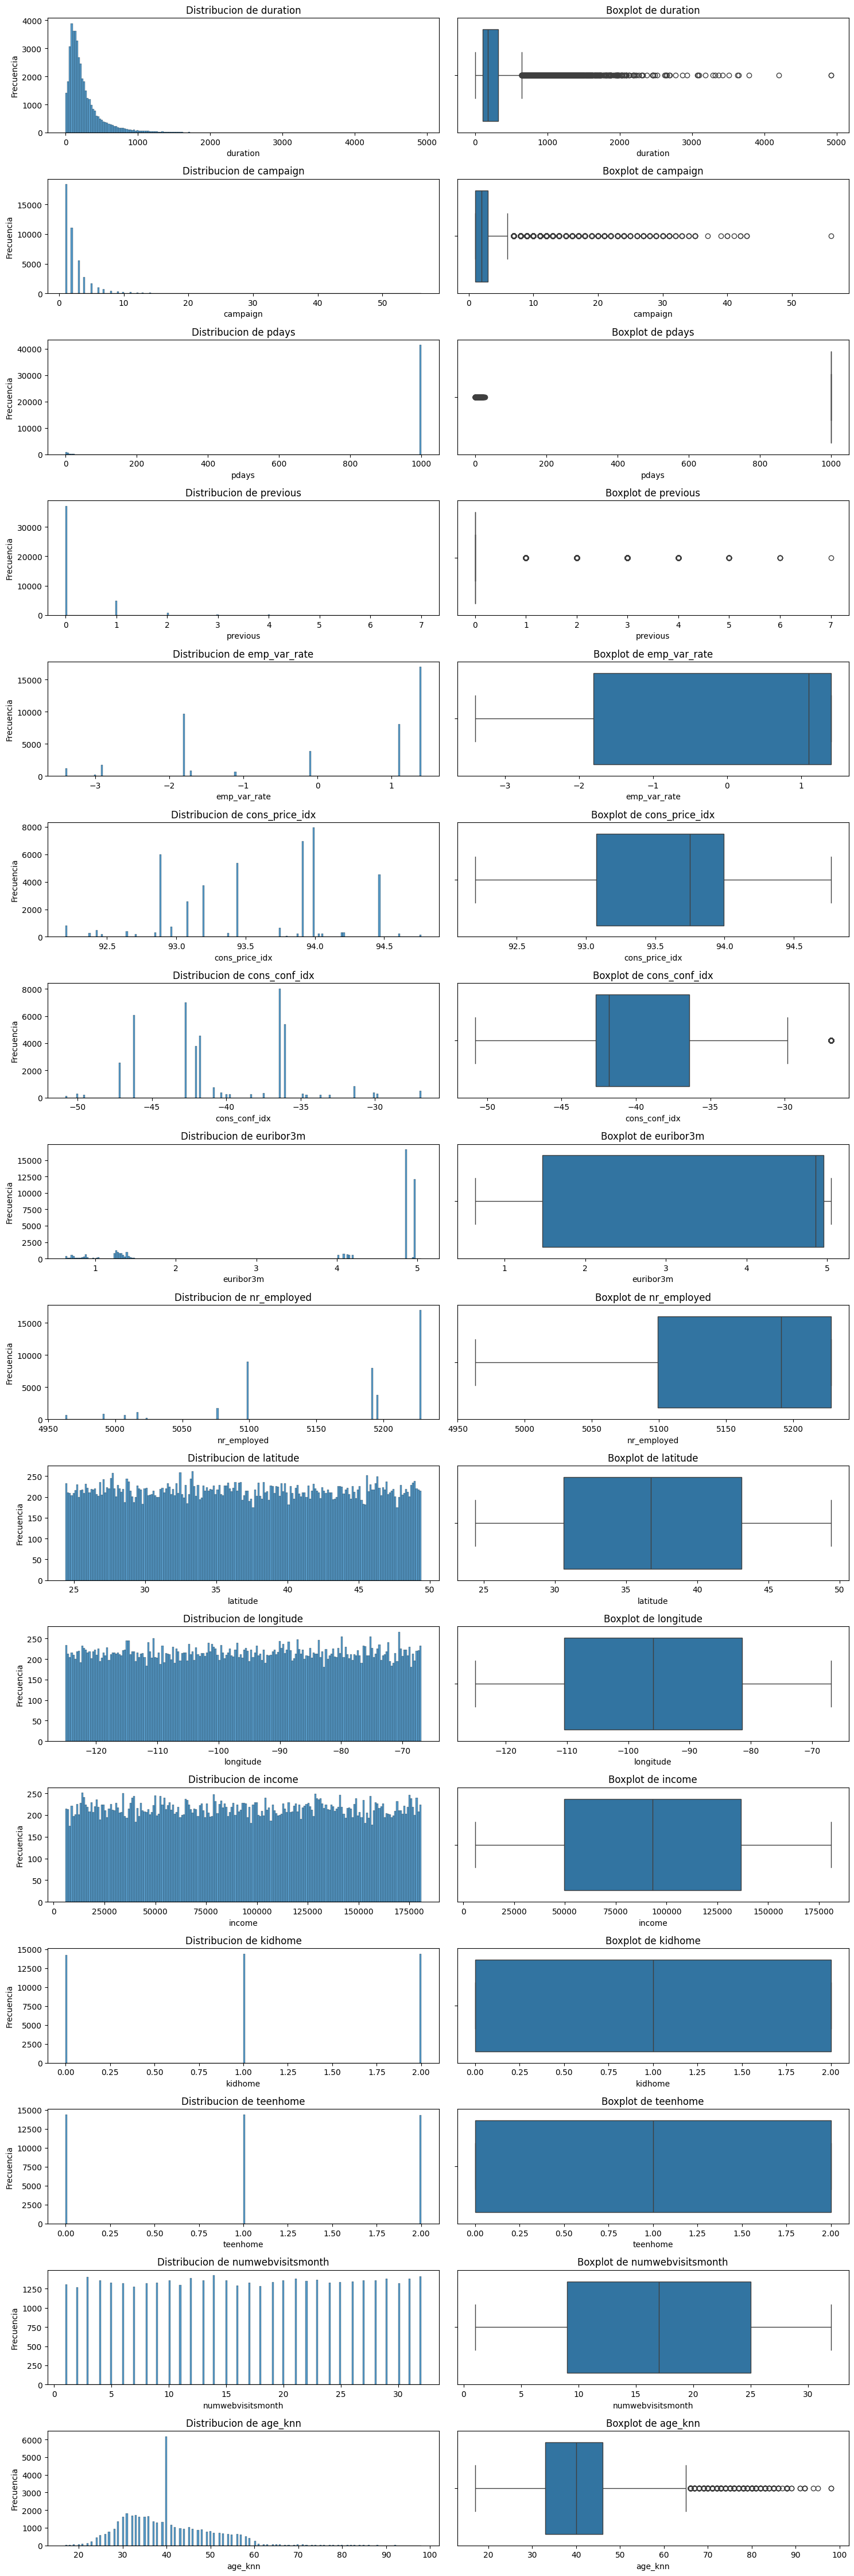

In [5]:
sn.subplot_col_num(df_no_nulos)

## Outliers

In [22]:
df_no_nulos.select_dtypes(include=['int64', 'float64']).describe().T

,count,mean,std,min,25%,50%,75%,max
duration,43000.0,257.739279,258.666033,0.000,102.00000,179.000000,319.00000,4918.000
campaign,43000.0,2.567233,2.772294,1.000,1.00000,2.000000,3.00000,56.000
pdays,43000.0,962.330953,187.260394,0.000,999.00000,999.000000,999.00000,999.000
previous,43000.0,0.174023,0.497366,0.000,0.00000,0.000000,0.00000,7.000
emp_var_rate,43000.0,0.077128,1.573898,-3.400,-1.80000,1.100000,1.40000,1.400
cons_price_idx,43000.0,93.576134,0.576652,92.201,93.07500,93.749000,93.99400,94.767
cons_conf_idx,43000.0,-40.509049,4.637186,-50.800,-42.70000,-41.800000,-36.40000,-26.900
euribor3m,43000.0,3.883541,1.621095,0.634,1.46600,4.857000,4.95900,5.045
nr_employed,43000.0,5166.665860,72.488304,4963.000,5099.00000,5191.000000,5228.00000,5228.000
latitude,43000.0,36.856697,7.225948,24.396,30.61475,36.761000,43.11325,49.384


In [6]:
sn.calculo_outliers(df_no_nulos,['duration', 'campaign', 'pdays', 'previous', 'cons_conf_idx', 'age_knn'])

En la columna DURATION tenenemos un total de 3072 outliers, lo que representa un 7.144186046511628% del total
En la columna CAMPAIGN tenenemos un total de 2504 outliers, lo que representa un 5.823255813953488% del total
En la columna PDAYS tenenemos un total de 1588 outliers, lo que representa un 3.6930232558139533% del total
En la columna PREVIOUS tenenemos un total de 5897 outliers, lo que representa un 13.713953488372093% del total
En la columna CONS_CONF_IDX tenenemos un total de 477 outliers, lo que representa un 1.1093023255813954% del total
En la columna AGE_KNN tenenemos un total de 576 outliers, lo que representa un 1.3395348837209302% del total


* **Duration** muestra una gran concentracion de los datos al inicio del histiograma. En el Boxplot se puede apreciar una gran cantidad de outliers.
* **campaign** muestra concentradas elevadas frecuencias en los valores al inicio del hitiograma, que se van haciendo mas pequenhos a medida que se desplaza hacia la derecha. Presentandonumerosos outliers a la derecha del boxplot.
* **Pdays** muestra concentracion de datos al incio del hisitiograma. En el Boxplot se puede apreciar una gran cantidad de outliers.
* **previous** muestra una gran concentracion de los datos para el valor 0 de numero de contratos antes de la campaña y valores atipicos a la derecha con un limite de 7 contratos.
* **cons_conf_idx** muestra altas frecuencias para valores de cons_conf_idx entre -50 y -35. Presentando outliers a la derecha de -30.
* **age_knn** muestra una especie de campana de gaus en el rango de edades entre 20 y 60 años. En el Boxplot podermos apreciar outliers a la derecha de ese rango.   

*  En el calculo numerico podemos ver que en **cons_conf_idx** los outliers suponen un 1.11%, lo que significa que podrian ser eliminados. Pero dado que no presentan frecuencias altas no parece que puedan afectar a otras medidas estadisticas. Asi que no los eliminaremos. En el caso de **age_knn** tampoco es un % excesivo de outliers pero dado que estamos hablando de edades, el eliminarlos podria afectar a determinados aspectos del analisis. En los otros casos tampoco los eliminaremos ya que suponen % elevados de outliers, lo que afectaria al analisis. 

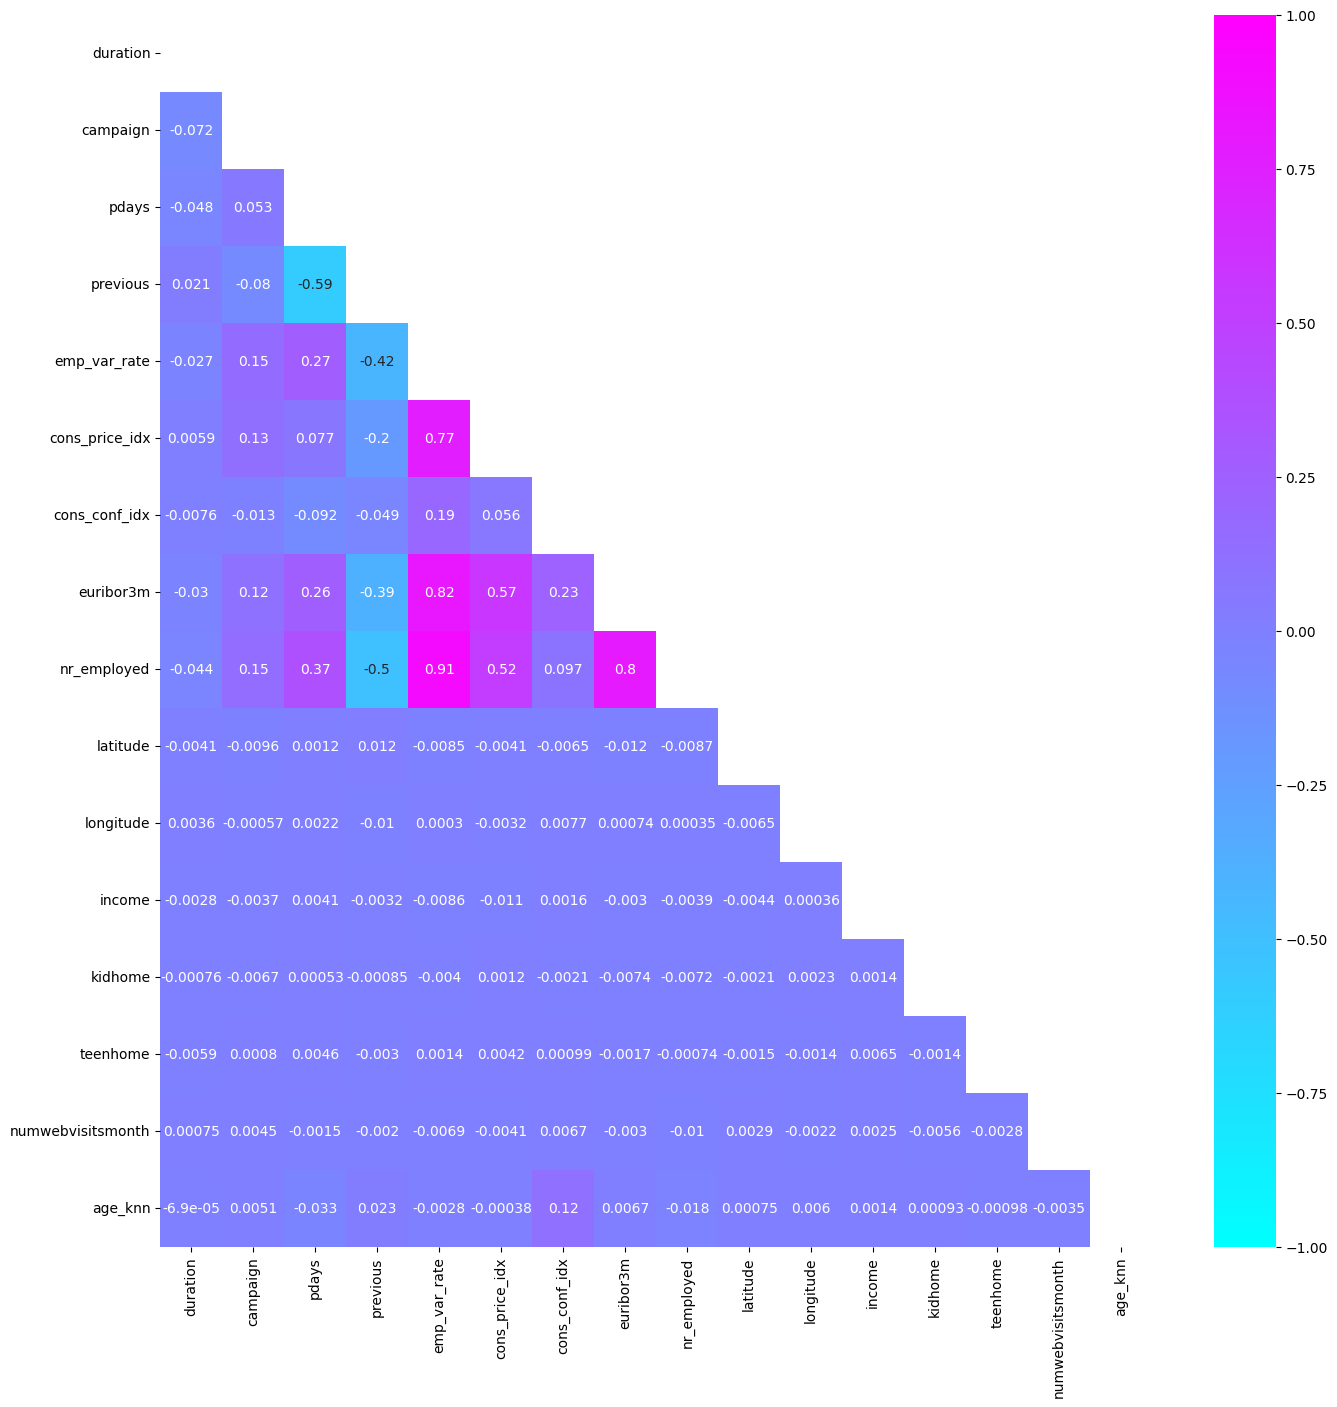

In [7]:
sv.matriz_correlacion(df_no_nulos)

## Conclusiones matriz de correlación

- **pdays** Correlacion media/baja positiva con **nr_employed** y correlacion media negativa con **previous** 
- **previous** correlacion media negativa con **nr_employed** , **euribor3m**  y **emp_var_rate**
- **emp_var_rate** correlacion alta positiva con **nr_employed** , **euribor3m** y **cons_price_idx**
- **cons_price_idx** correlacion media positiva con **nr_employed** y **euribor3m**
- **euribor3m** correlacion alta positiva con **nr_employed**


- **pdays** podria tener sentido la relacion con **nr_employed** pero no tiene sentido la relacion con **previous** no podemos establecer una relacion con   
                    previous ya que esta se refiere a datos disntintos a los de la campaña actual
- **previous** no tiene sentido la relacion con **nr_employed**, **euribor3m**  y **emp_var_rate** ya que estos son datos durante la actual camapaña
- **emp_var_rate**:
                    -Tiene sentido tener una fuerte relacion con **nr_employed** si la tasa de variancion de empleo es positiva el numero de empleados sube
                    -Relacion positiva con **euribor3m**. Aunque pueda parecer contradictorio puede tener sentido en excenario de recuperacion economica. Cuando el empleo mejora los tipos de interes suben como medida contencion y cuando el empleo empeora los tipos se bajan como medida expansiva.
                    -Tiene sentido tener una fuerte Relacion positiva con **cons_price_idx**, al subir el empleo se incrementa el numero de personas con capacidad de adquisitiva y por tanto de consumo.
- **cons_price_idx**:
                    -Tiene sentido tener una relacion positiva con **nr_employed** ya que al aumentar el numero de empleos se incrementa la posibilidad de consumo y por tanto la tendencia alcista de los precios. Que sea una relacion media y no alta se puede deber a que hay mas factores que influyen en los movimientos de lod precios. 

                    - Tiene sentido la relacion positiva con el **euribor3m** ya que al subir los precios, los tipos de interes suben como medida antiflacionista. Que sea una relacion media y no alta se puede deber a que hay mas factores que influyen en los movimientos del euribor.
**euribor3m**:      
                    -Esta relacion alta positiva tiene sentido ya que cuando la    
                    economia crece, las empresas contratan, al contratar hay mas consumo, por tanto mayor inflacion y en consecuencia mayores politicas restrictivas como la subida de los tipos de interes.                  

## Mapa de ubicacion de clientes

In [8]:
import plotly.express as px

In [9]:
df_lat_lon = df_no_nulos[(df_no_nulos['latitude'].isna() == False) & (df_no_nulos['longitude'].isna() == False)]

fig = px.scatter_map(
    df_lat_lon,
    lat='latitude',
    lon='longitude',
    size='income',
    size_max=1,
    zoom=1,
    map_style='open-street-map',
    hover_name='id'   # ahora muestra el ID del cliente
)
fig.show()

* Habria que consultar con el proveedor de los datos ya que parece haber un error en las coordenadas. Tratandose de un Banco Portugues cabe pensar que sus clientes sean de Portugal, pero el grafico muestra localizacion en Norteamerica. Ademas, la distribucion de los puntos es muy homogenea, incluso saliendose de el perimetro continental. Todo indica que se puede tratar de datos erroneos.

## FECHAS

### Evolucion de productos contratados

#ELIMINAR CELDA


meses = {
    'enero':'01', 'febrero':'02', 'marzo':'03', 'abril':'04',
    'mayo':'05', 'junio':'06', 'julio':'07', 'agosto':'08',
    'septiembre':'09', 'octubre':'10', 'noviembre':'11', 'diciembre':'12'
}

for mes_texto, mes_num in meses.items():
    df_no_nulos['date_contact'] = df_no_nulos['date_contact'].str.replace(mes_texto, mes_num)


for col in ['date_contact', 'dt_customer']:
    df_no_nulos[col] = pd.to_datetime(df_no_nulos[col], dayfirst=True, errors='coerce')

<Axes: xlabel='date_contact', ylabel='subscription_prod'>

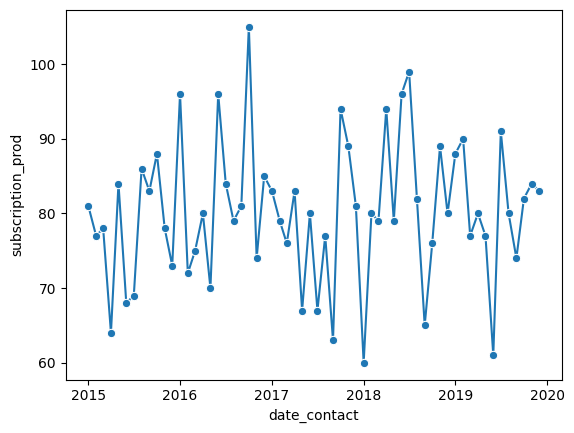

In [10]:
df_date_subs_prod = df_no_nulos[df_no_nulos['subscription_prod'] == 'yes'].groupby(df_no_nulos['date_contact'].dt.to_period('M'))['subscription_prod'].count().reset_index()
df_date_subs_prod['date_contact'] = df_date_subs_prod ['date_contact'].dt.to_timestamp()

sns.lineplot(x='date_contact', y = 'subscription_prod', data = df_date_subs_prod,
             marker = "o" )


*   La exitos de la campaña parcen concentrarse en torno a un 80 numero de subscripciones durante los distintos años
*   Donde mas exito ha tenido ha sido en: Enero, Junio y Octubre de **2016**. En Octubre de **2017**. En Abril, Junio y Julio de **2018** y Julio de**2019**
*   Donde menos exito se ha tenido ha sido en: Abril, Junio y Julio de **2015**, en Mayo, Julio y Septiembre de **2017**, Enero y septiembre de **2018** y Junio de **2019**
                                        

## Estudio de variables correlacionadas

### emp_var_rate y nr_employed

<Axes: xlabel='emp_var_rate', ylabel='nr_employed'>

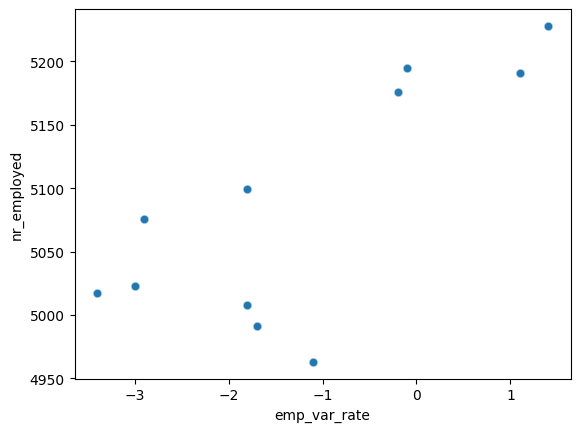

In [11]:
sns.scatterplot(x = "emp_var_rate", y="nr_employed", data = df_no_nulos, alpha = 0.25)

* El data frame tiene muschas filas con valores repetidos en las mismas combinaciones de emp_var_rate y nr_employed. Por eso no se ve una gran cantidad de puntos en el grafico. Exceptuando 3 de los puntos de emp_var_rate en general se ve una tendencia de que al desplazarse a la derecha los valores en nr_emplyed crecen

### emp_var_rate y euribor3m

<Axes: xlabel='emp_var_rate', ylabel='euribor3m'>

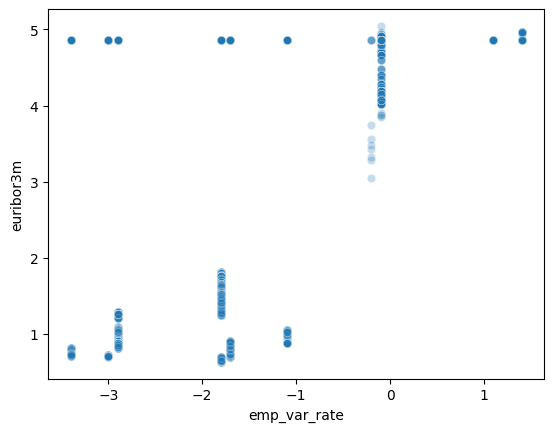

In [12]:
sns.scatterplot(x = "emp_var_rate", y="euribor3m", data = df_no_nulos, alpha = 0.25)

* Hay 3 o cuatro valores para los cuales cuando la tasa de empleo se mantuvo en un determinado valor, el euribor ha oscilado entre distitos valores. Esto puede ser consecuencia de que el Euribor, a pesar de verse afectado por la tasa de empleo, al mismo tiempo depende de otros facores.

### nr_employed y cons_price_idx

<Axes: xlabel='emp_var_rate', ylabel='cons_price_idx'>

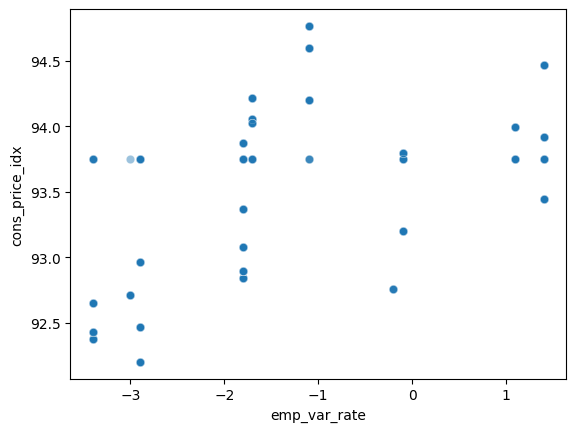

In [13]:
sns.scatterplot(x = "emp_var_rate", y="cons_price_idx", data = df_no_nulos, alpha = 0.25)

* Aqui podermos encontrar de nuevo no demasiados puntos ya que, de la misma manera que en los casos anteriores, hay unos pocos valores que se repiten. Quizas aqui estan algo mas dispersos por lo que para los distintos valores de la tasa de empleo el indice de precios de consumo ha variado un poco mas en cada punto. Si se puede apreciar una tendencia general de que al desplazarse a la derecha la tasa de empleo, el indice de precios de consumo tiende a ir creciendo tambien.

### Relaciones cruzadas

In [14]:
df_no_nulos.columns

Index(['job', 'marital', 'education', 'contact', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'subscription_prod',
       'date_contact', 'latitude', 'longitude', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'numwebvisitsmonth', 'id', 'default_str',
       'housing_str', 'loan_str', 'age_knn'],
      dtype='object')

In [15]:
df_no_nulos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   job                43000 non-null  object        
 1   marital            43000 non-null  object        
 2   education          43000 non-null  object        
 3   contact            43000 non-null  object        
 4   duration           43000 non-null  int64         
 5   campaign           43000 non-null  int64         
 6   pdays              43000 non-null  int64         
 7   previous           43000 non-null  int64         
 8   poutcome           43000 non-null  object        
 9   emp_var_rate       43000 non-null  float64       
 10  cons_price_idx     43000 non-null  float64       
 11  cons_conf_idx      43000 non-null  float64       
 12  euribor3m          43000 non-null  float64       
 13  nr_employed        43000 non-null  int64         
 14  subscr

### COLUMNAS NUMERICAS

In [16]:
col_num = 'age_knn'
cols_num = df_no_nulos.select_dtypes(include='number').columns
cols_num

Index(['duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed',
       'latitude', 'longitude', 'income', 'kidhome', 'teenhome',
       'numwebvisitsmonth', 'age_knn'],
      dtype='object')

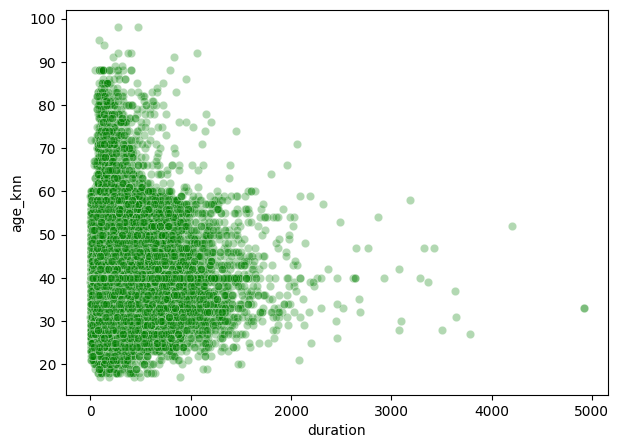

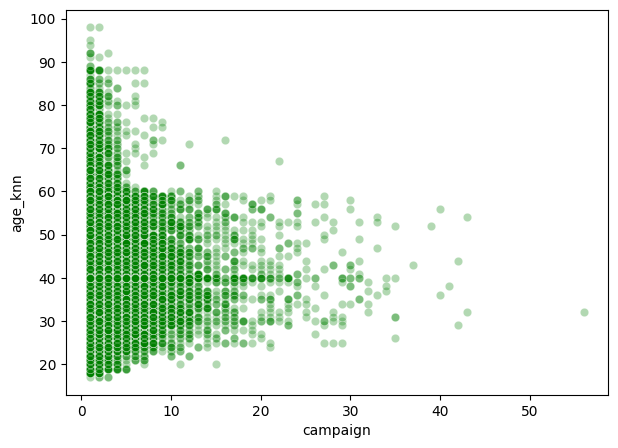

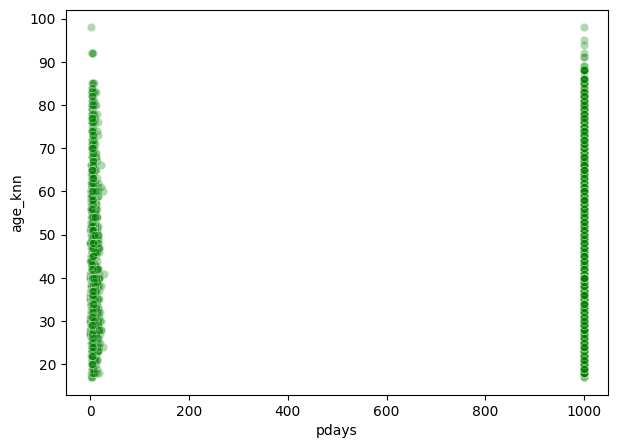

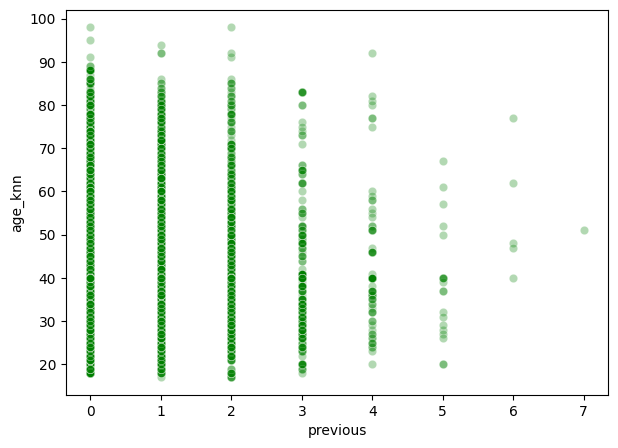

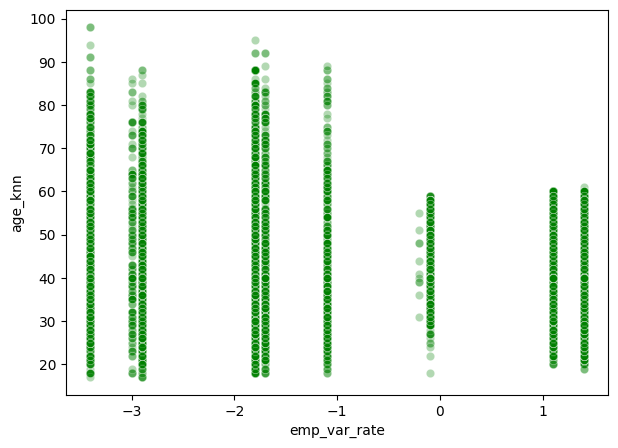

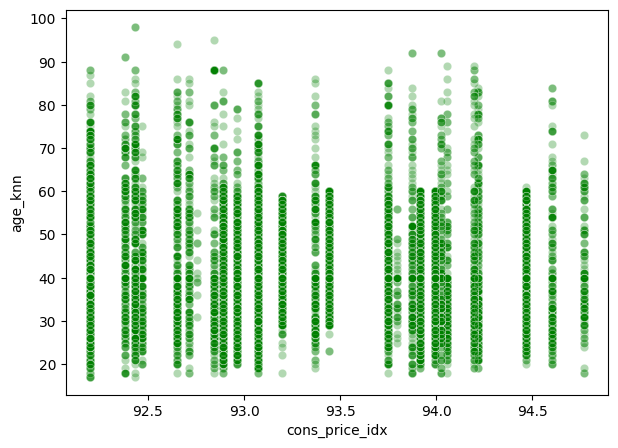

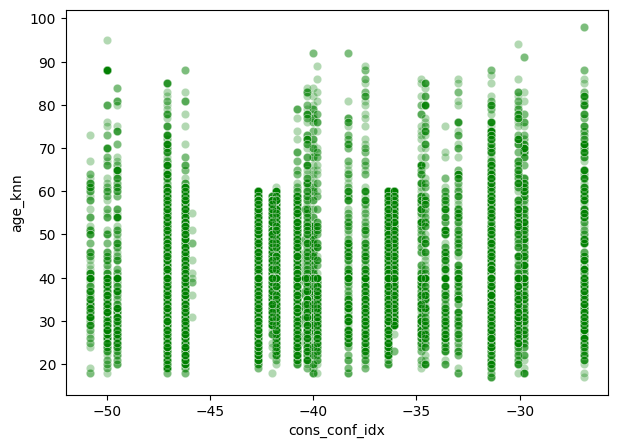

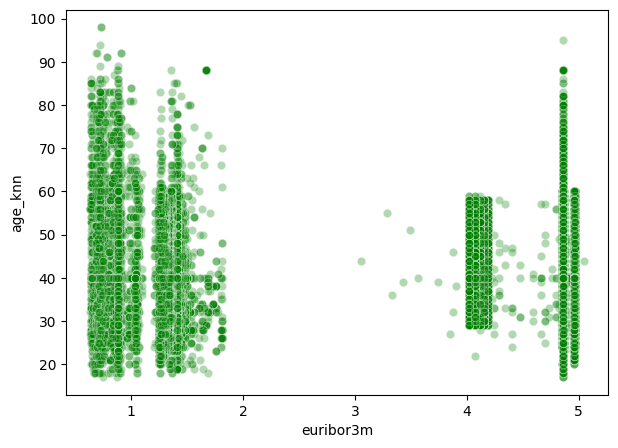

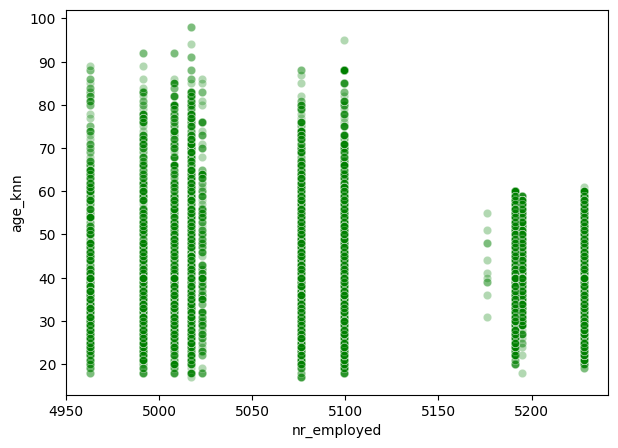

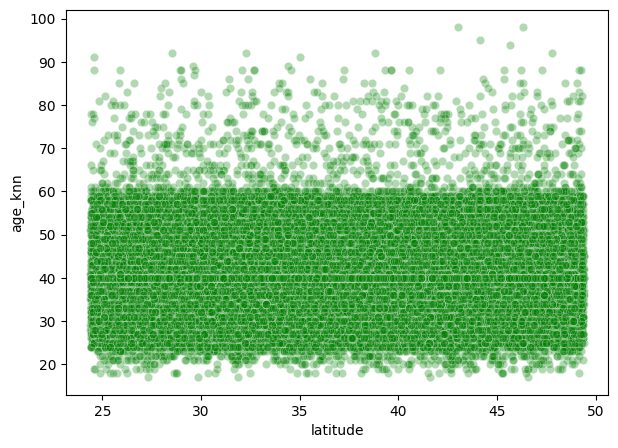

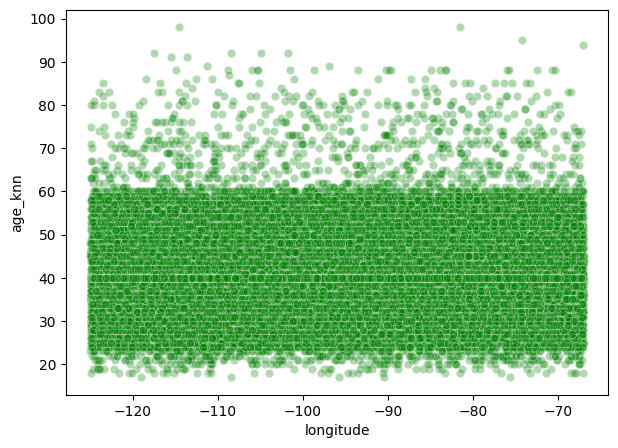

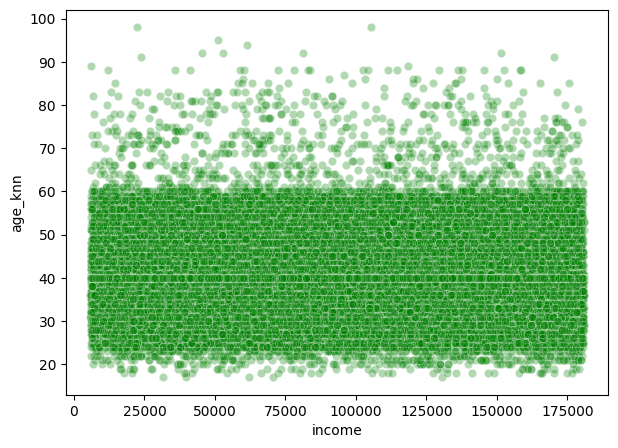

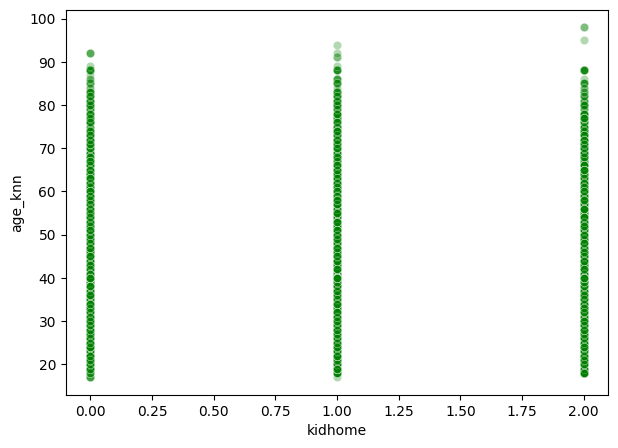

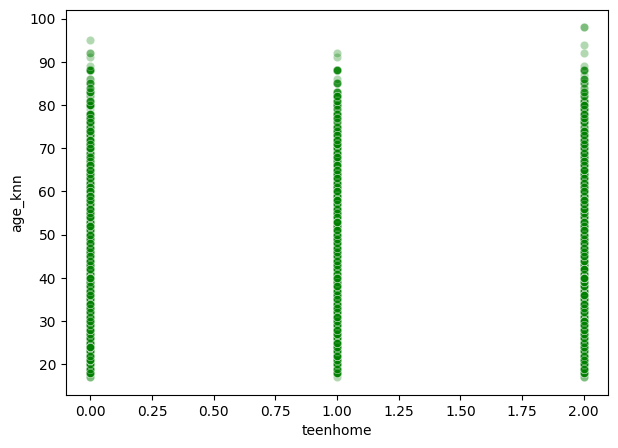

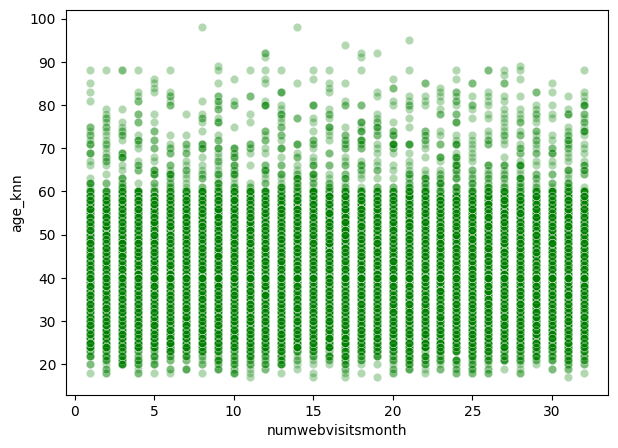

In [17]:
for col in cols_num:
    if col == col_num:
        continue
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df_no_nulos, x= col, y=col_num, color= 'green', alpha= 0.3)
    #plt.yscale('log')
    plt.show()

### COLUMNAS CATEGORICAS

In [18]:
from SRC import sp_eda as se    ##### eliminar al terminar comprobacion

In [19]:
print ('FRECUENCIA CATEGORICAS')    ##### eliminar al terminar comprobacion
for col in df_no_nulos.select_dtypes(include='object').columns:
    print(col.upper())
    print((df_no_nulos[col].value_counts(normalize=True) * 100).round(2))
    print('------------')

FRECUENCIA CATEGORICAS
JOB
job
admin            25.29
blue_collar      22.45
technician       16.34
services          9.68
management        7.09
retired           4.16
entrepreneur      3.54
self_employed     3.46
housemaid         2.61
unemployed        2.47
student           2.10
unknown           0.80
Name: proportion, dtype: float64
------------
MARITAL
marital
married     60.66
single      28.15
divorced    11.19
Name: proportion, dtype: float64
------------
EDUCATION
education
university_degree      29.59
high_school            23.08
basic_9y               14.67
professional_course    12.74
basic_4y               10.13
basic_6y                5.55
unknown                 4.20
illiterate              0.04
Name: proportion, dtype: float64
------------
CONTACT
contact
cellular     63.71
telephone    36.29
Name: proportion, dtype: float64
------------
POUTCOME
poutcome
nonexistent    86.29
failure        10.37
success         3.34
Name: proportion, dtype: float64
------------
SUBSCR

In [20]:
col_num = 'age_knn'

cols_cat = df_no_nulos.select_dtypes(include=['category','object']).columns


cols_cat

Index(['job', 'marital', 'education', 'contact', 'poutcome',
       'subscription_prod', 'id', 'default_str', 'housing_str', 'loan_str'],
      dtype='object')

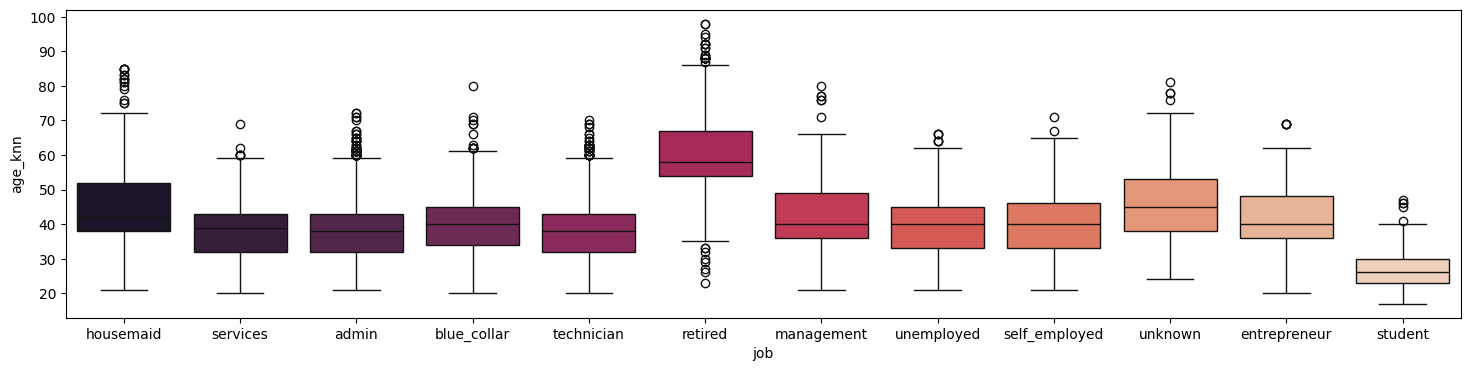

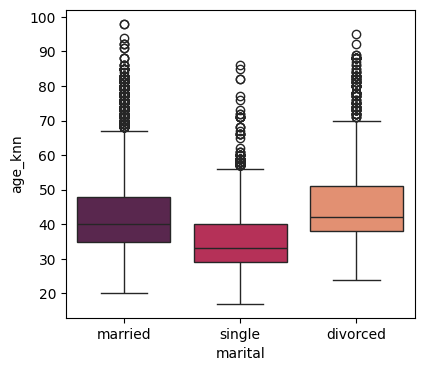

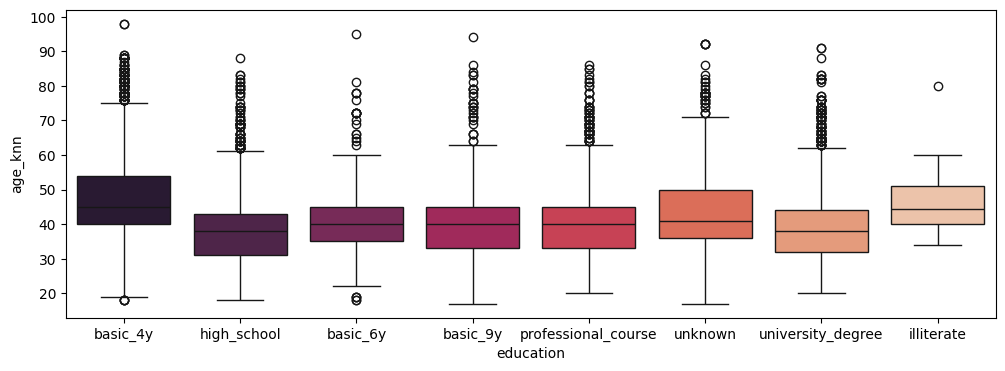

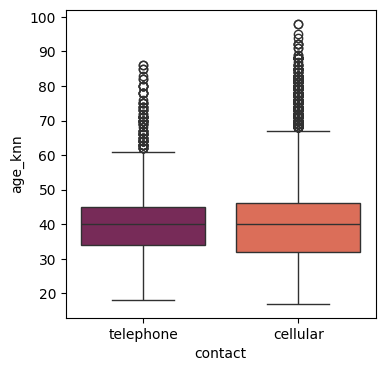

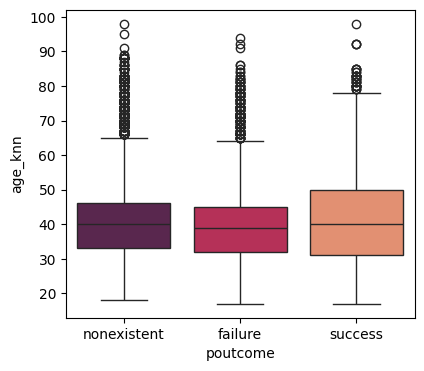

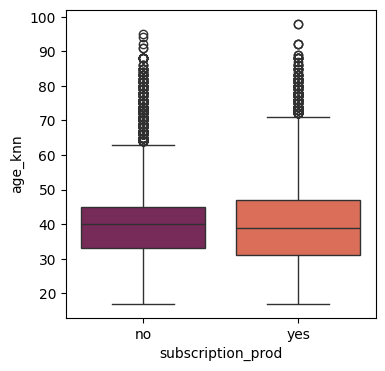

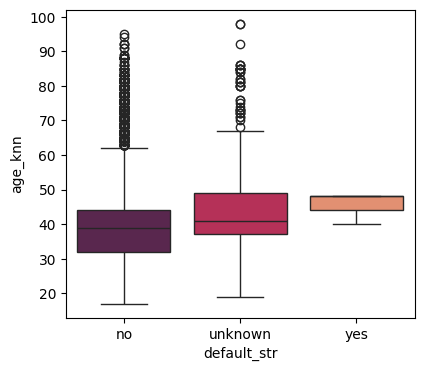

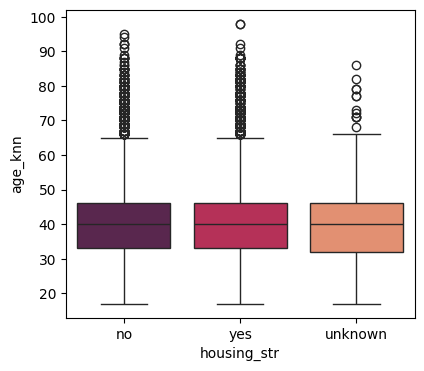

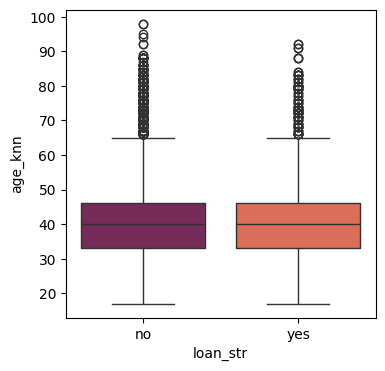

In [21]:
col_num = 'age_knn'

cols_cat = df_no_nulos.select_dtypes(include=['category','object']).columns

for col in cols_cat:
    if col=='date_contact':
        continue
    if col=='dt_customer':
        continue
    if col=='id':
        continue
    # calcular el numero de categorias unicas
    num_cats = df_no_nulos[col].nunique()
    
    # Ajustar dinamicamente el tamaño del grafico
    fig_width = max(4, num_cats * 1.5)
    fig_height = 4

    cats_ordenadas = df_no_nulos.groupby(col)[col_num].mean().sort_values().index # para odernar en este caso por edad
    plt.figure(figsize=(fig_width, fig_height))
    sns.boxplot(x=df_no_nulos[col], y=df_no_nulos[col_num],hue=df_no_nulos[col], palette='rocket') # order = cats_ordernadas (si queremos ordenar por edad)
    plt.show()
    
   

    